# LDA Feature Extraction

implement Linear Discriminant Analysis (LDA) from scratch and apply it to extract features from the face dataset.

**Objectives:**
1. Implement LDA from scratch (without using sklearn.discriminant_analysis.LinearDiscriminantAnalysis)
2. Apply LDA with 2 and 3 components for visualization
3. Apply LDA with 10 and 20 components for Part 2 preparation
4. Visualize fisherfaces and projected data
5. Highlight selfie samples in visualizations
6. Compare LDA with PCA results

In [1]:
import os
import sys
import numpy as np
import traceback
from pathlib import Path

from matplotlib import pyplot as plt

sys.path.append(str(Path().absolute().parent))

from src.data.data_loader import load_config
from src.preprocessing.lda import compute_lda
from src.visualization.plotter import (
    plot_lda_2d, plot_lda_3d, plot_fisherfaces
)

## Load Configuration and Data

In [2]:
config = load_config()
print(f"Using seed value: {config['seed']}")

try:
    
    # Load processed data
    x_train = np.load('../Outputs/data/x_train.npy')
    y_train = np.load('../Outputs/data/y_train.npy')
    train_selfie_indices = np.load('../Outputs/data/train_selfie_indices.npy')
    
    print(f"Loaded training data: {x_train.shape}")
    print(f"Training labels: {y_train.shape}")
    print(f"Number of classes: {len(np.unique(y_train))}")
    print(f"Number of selfie samples in training: {len(train_selfie_indices)}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    print(traceback.format_exc(limit=3))

Using seed value: 963
Loaded training data: (2978, 1024)
Training labels: (2978,)
Number of classes: 25
Number of selfie samples in training: 7


## Part I: LDA for Visualization

### LDA with 2 Components

In [3]:
try:
    print("Computing LDA with 2 components for 2D visualization...")
    
    lda_vectors_2, x_train_lda_2 = compute_lda(x_train, y_train, 2)
    
    print(f"LDA vectors shape: {lda_vectors_2.shape}")
    print(f"Transformed data shape: {x_train_lda_2.shape}")
    
    unique_classes = np.unique(y_train)
    print(f"LDA successfully separated {len(unique_classes)} classes")
    
except Exception as e:
    print(f"Error in LDA with 2 components: {e}")
    print(traceback.format_exc(limit=3))

Computing LDA with 2 components for 2D visualization...
LDA vectors shape: (1024, 2)
Transformed data shape: (2978, 2)
LDA successfully separated 25 classes


In [4]:
os.makedirs('../Outputs/lda', exist_ok=True)
try:
    
    #visualize 2D LDA projection
    plot_lda_2d(x_train_lda_2, y_train, train_selfie_indices,
               save_path="../Outputs/lda/lda_2d_visualization.png", show=False)
    print("2D LDA visualization saved to ../Outputs/lda/lda_2d_visualization.png")
    
    #visualize fisherfaces (2 components)
    plot_fisherfaces(lda_vectors_2, n_components=2,
                    save_path='../Outputs/lda/fisherfaces_2.png', show=False)
    print("Fisherfaces (2 components) saved to ../Outputs/lda/fisherfaces_2.png")
    
except Exception as e:
    print(f"Error visualizing 2D LDA results: {e}")
    print(traceback.format_exc(limit=3))

2D LDA visualization saved to ../Outputs/lda/lda_2d_visualization.png
Fisherfaces (2 components) saved to ../Outputs/lda/fisherfaces_2.png


### LDA with 3 Components

In [5]:
try:
    print("Computing LDA with 3 components for 3D visualization...")
    
    lda_vectors_3, x_train_lda_3 = compute_lda(x_train, y_train, 3)
    
    print(f"LDA vectors shape: {lda_vectors_3.shape}")
    print(f"Transformed data shape: {x_train_lda_3.shape}")
    
except Exception as e:
    print(f"Error in LDA with 3 components: {e}")
    print(traceback.format_exc(limit=3))

Computing LDA with 3 components for 3D visualization...
LDA vectors shape: (1024, 3)
Transformed data shape: (2978, 3)


In [6]:
try:
    #visualize 3D LDA projection
    plot_lda_3d(x_train_lda_3, y_train, train_selfie_indices,
               save_path='../Outputs/lda/lda_3d_visualization.png', show=False)
    print("3D LDA visualization saved to ../Outputs/lda/lda_3d_visualization.png")
    
    #visualize fisherfaces (3 components)
    plot_fisherfaces(lda_vectors_3, n_components=3,
                    save_path='../Outputs/lda/fisherfaces_3.png', show=False)
    print("Fisherfaces (3 components) saved to ../Outputs/lda/fisherfaces_3.png")
    
except Exception as e:
    print(f"Error visualizing 3D LDA results: {e}")
    print(traceback.format_exc(limit=3))

3D LDA visualization saved to ../Outputs/lda/lda_3d_visualization.png
Fisherfaces (3 components) saved to ../Outputs/lda/fisherfaces_3.png


## Part II: LDA for Feature Extraction (Preparation for Part 2)

### LDA with 10 Components

In [7]:
try:
    print("Computing LDA with 10 components for feature extraction...")
    
    lda_vectors_10, x_train_lda_10 = compute_lda(x_train, y_train, 10)
    
    print(f"LDA vectors shape: {lda_vectors_10.shape}")
    print(f"Transformed data shape: {x_train_lda_10.shape}")
    
    # Analyze discriminative power
    print(f"Reduced dimensionality from {x_train.shape[1]} to 10 components")
    print(f"LDA maximizes between-class scatter while minimizing within-class scatter")
    
except Exception as e:
    print(f"Error in LDA with 10 components: {e}")
    print(traceback.format_exc(limit=3))

Computing LDA with 10 components for feature extraction...
LDA vectors shape: (1024, 10)
Transformed data shape: (2978, 10)
Reduced dimensionality from 1024 to 10 components
LDA maximizes between-class scatter while minimizing within-class scatter


### LDA with 20 Components

In [8]:
try:
    print("Computing LDA with 20 components for feature extraction...")
    
    lda_vectors_20, x_train_lda_20 = compute_lda(x_train, y_train, 20)
    
    print(f"LDA vectors shape: {lda_vectors_20.shape}")
    print(f"Transformed data shape: {x_train_lda_20.shape}")
    
    #max_components for LDA is limited by (number of classes - 1)
    max_components = len(np.unique(y_train)) - 1
    print(f"Maximum possible LDA components: {max_components} (classes - 1)")
    
except Exception as e:
    print(f"Error in LDA with 20 components: {e}")
    print(traceback.format_exc(limit=3))

Computing LDA with 20 components for feature extraction...
LDA vectors shape: (1024, 20)
Transformed data shape: (2978, 20)
Maximum possible LDA components: 24 (classes - 1)


## Save LDA Features for Part 2

In [9]:
try:
    # Create output directory
    os.makedirs('../Outputs/features', exist_ok=True)
    
    # Save LDA features and vectors for Part 2
    np.save('../Outputs/features/lda_10_features.npy', x_train_lda_10)
    np.save('../Outputs/features/lda_10_vectors.npy', lda_vectors_10)
    print("LDA features (10 components) saved to ../Outputs/features/")
    
    np.save('../Outputs/features/lda_20_features.npy', x_train_lda_20)
    np.save('../Outputs/features/lda_20_vectors.npy', lda_vectors_20)
    print("LDA features (20 components) saved to ../Outputs/features/")
    
except Exception as e:
    print(f"Error saving LDA features: {e}")
    print(traceback.format_exc(limit=3))

LDA features (10 components) saved to ../Outputs/features/
LDA features (20 components) saved to ../Outputs/features/


## Compare LDA with PCA Results

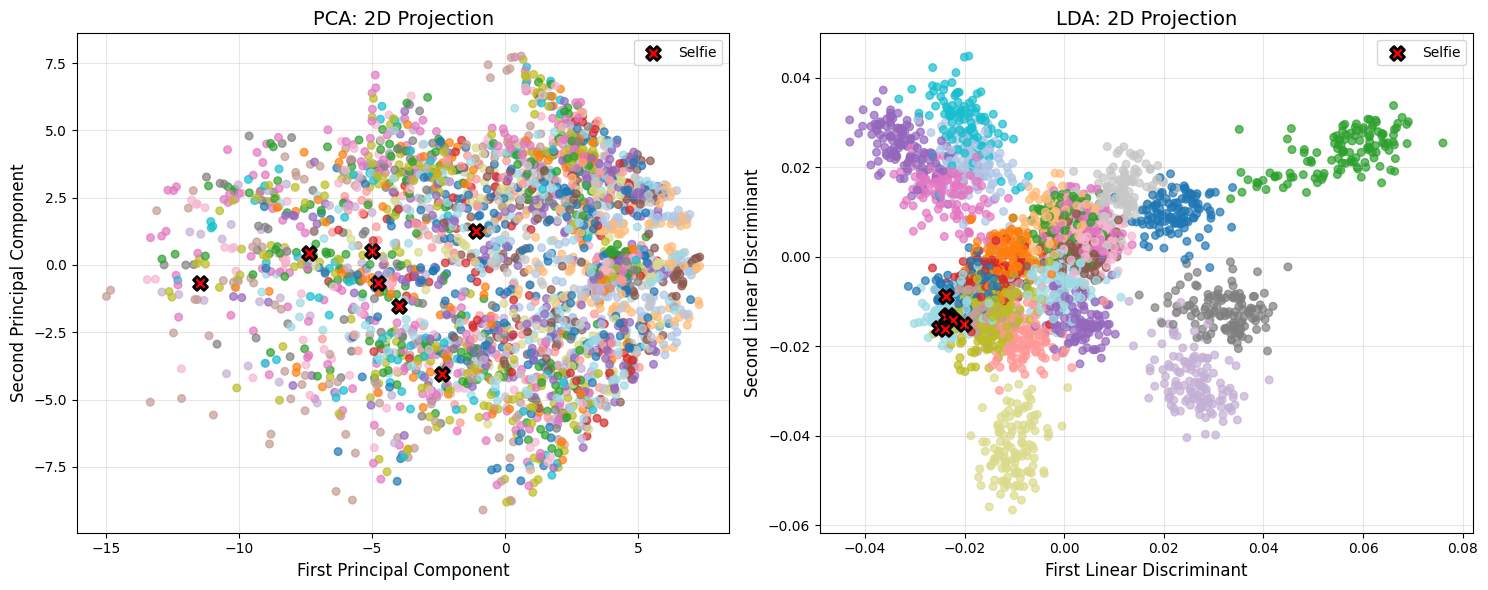

Comparison plot saved to ../Outputs/lda/pca_vs_lda_comparison.png


In [12]:
try:
    #load pca results
    x_train_pca_2 = np.load('../Outputs/features/pca_2_features.npy')
    
    #compare class separation in PCA vs LDA
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    #pca 2D projection
    scatter1 = ax1.scatter(x_train_pca_2[:, 0], x_train_pca_2[:, 1], 
                          c=y_train, cmap='tab20', alpha=0.7, s=30)
    
    #highlight selfie samples in PCA
    if len(train_selfie_indices) > 0:
        ax1.scatter(x_train_pca_2[train_selfie_indices, 0], 
                  x_train_pca_2[train_selfie_indices, 1], 
                  c='red', s=100, marker='X', linewidths=2, 
                  edgecolors='black', label='Selfie')
    
    ax1.set_xlabel('First Principal Component')
    ax1.set_ylabel('Second Principal Component')
    ax1.set_title('PCA: 2D Projection')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    #lda 2D projection
    scatter2 = ax2.scatter(x_train_lda_2[:, 0], x_train_lda_2[:, 1], 
                          c=y_train, cmap='tab20', alpha=0.7, s=30)
    
    #highlight selfie samples in LDA
    if len(train_selfie_indices) > 0:
        ax2.scatter(x_train_lda_2[train_selfie_indices, 0], 
                  x_train_lda_2[train_selfie_indices, 1], 
                  c='red', s=100, marker='X', linewidths=2, 
                  edgecolors='black', label='Selfie')
    
    ax2.set_xlabel('First Linear Discriminant')
    ax2.set_ylabel('Second Linear Discriminant')
    ax2.set_title('LDA: 2D Projection')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../Outputs/lda/pca_vs_lda_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Comparison plot saved to ../Outputs/lda/pca_vs_lda_comparison.png")
    
except Exception as e:
    print(f"Error comparing PCA and LDA results: {e}")
    print(traceback.format_exc(limit=3))

## Analyze Class Separation

In [13]:
def calculate_class_separation(features, labels):
	"""
	Calculate average inter-class and intra-class distances.
	
	Args:
		features (np.ndarray): Feature matrix of shape (n_samples, n_features).
		labels (np.ndarray): Class labels of shape (n_samples,).
		
	Returns:
		tuple: (average_intra_class_distance, average_inter_class_distance)
	"""
	unique_classes = np.unique(labels)
	
	#intra-class distances
	intra_class_distances = []
	for class_label in unique_classes:
		class_indices = np.where(labels == class_label)[0]
		class_features = features[class_indices]
		
		if len(class_features) > 1:
			
			#calc pairwise distances within class
			distances = []

			for i in range(len(class_features)):
				for j in range(i+1, len(class_features)):
					dist = np.linalg.norm(class_features[i] - class_features[j])
					distances.append(dist)
			intra_class_distances.extend(distances)
	
	#inter-class distances
	inter_class_distances = []
	class_centers = []
	
	for class_label in unique_classes:
		class_indices = np.where(labels == class_label)[0]
		class_features = features[class_indices]
		class_center = np.mean(class_features, axis=0)
		class_centers.append(class_center)
	
	for i in range(len(class_centers)):
		for j in range(i+1, len(class_centers)):
			dist = np.linalg.norm(class_centers[i] - class_centers[j])
			inter_class_distances.append(dist)
	
	return np.mean(intra_class_distances), np.mean(inter_class_distances)

In [ ]:
#compare separation for PCA vs LDA
try:
    
    pca_intra, pca_inter = calculate_class_separation(x_train_pca_2, y_train)
    lda_intra, lda_inter = calculate_class_separation(x_train_lda_2, y_train)
    
    print(f"PCA - intra-class distance: {pca_intra:.4f}, inter-class distance: {pca_inter:.4f}")
    print(f"LDA - intra-class distance: {lda_intra:.4f}, inter-class distance: {lda_inter:.4f}")
    print(f"LDA/PCA inter-class ratio: {lda_inter/pca_inter:.4f}")
    print(f"LDA/PCA intra-class ratio: {lda_intra/pca_intra:.4f}")
    
    #better separation has higher inter-class and lower intra-class distances
    if lda_inter > pca_inter and lda_intra < pca_intra:
        print("LDA provides better class separation than PCA")
    else:
        print("Class separation comparison requires careful interpretation")
    
except Exception as e:
    print(f"Error analyzing class separation: {e}")
    print(traceback.format_exc(limit=3))

PCA - intra-class distance: 6.2426, inter-class distance: 2.6916
LDA - intra-class distance: 0.0075, inter-class distance: 0.0325
LDA/PCA inter-class ratio: 0.0121
LDA/PCA intra-class ratio: 0.0012
Class separation comparison requires careful interpretation
